# **Logistic Regression — ROC Curve & AUC Score**

So far, we've evaluated models using **Accuracy**, **Confusion Matrix**, and **Precision/Recall**. All of those depend on a single fixed decision threshold — normally, if the predicted probability is ≥ 0.5, we call it Class 1, otherwise Class 0.

But what if 0.5 isn't the best cutoff for our problem? The **ROC Curve** and **AUC Score** let us evaluate a model **across every possible threshold at once**, instead of being locked into just one.




In [1]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve               # computes the ROC curve points
from sklearn.metrics import roc_auc_score            # computes the single AUC score
from matplotlib import pyplot

## **Create a Practice Dataset**

We use `make_classification()` to generate fake data with 2 classes (0 and 1), just so we have something to train and test a model on. In a real project, this would be your actual dataset (customer churn, disease diagnosis, etc.).

In [2]:
# generate 2 class dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

## **Split Into Training and Testing Sets**

We train the model on one portion of the data (`train`) and evaluate it on data it has never seen before (`test`), so we get an honest measure of performance.

In [3]:
# Split the Dataset into train test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

## **Create a "No-Skill" Baseline (Dummy) Model**

Before evaluating our Logistic Regression model, it is important to establish a **baseline** for comparison.

A **dummy (no-skill) model** does not learn any patterns from the training data. Instead, it simply predicts the **majority class (Class 0)** for every test sample.

This baseline helps us determine whether our Logistic Regression model is actually learning meaningful patterns or merely achieving high performance by predicting the majority class. If the real model does not perform significantly better than the dummy model, it indicates that the model has learned very little from the data.

In [4]:
# Created a Dummy Model with default 0 as output (predicts "Class 0" every single time)
dummy_model_prob = [0 for _ in range(len(y_test))]
dummy_model_prob[:10]  # preview the first 10 values — they're all 0, as expected

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

## **Train a Real Logistic Regression Model**

Now let's train an actual model that learns from the data, instead of just guessing the same class every time.

In [5]:
# Let's Create a basic Logistic Model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## **Get Predicted Probabilities (Not Just Labels)**

Normally `model.predict(X_test)` gives you the final class label (0 or 1). But for ROC/AUC, we need the **probability** the model assigned to Class 1, before it gets rounded to a hard label.

`model.predict_proba(X_test)` returns **two columns**:
- Column 0 → probability of Class 0
- Column 1 → probability of Class 1

Since both columns always add up to 1 (e.g. `[0.3, 0.7]`), we only need column 1 (`[:, 1]`) — the probability of Class 1.

In [6]:
# Prediction Based on probability (returns probability for BOTH classes)
model_prob = model.predict_proba(X_test)

# lets focus on one output — the probability of Class 1 only
model_prob = model_prob[:, 1]

# preview the first 10 predicted probabilities
model_prob[:10]

array([0.91827626, 0.88665574, 0.02316745, 0.98189061, 0.95453132,
       0.79675072, 0.00683734, 0.05402391, 0.99130971, 0.40860135])

## **Compute the AUC Score**

The **AUC (Area Under the ROC Curve)** is a single number that tells us **how well our model can distinguish between Class 0 and Class 1**.

The AUC score always lies between **0 and 1**.

- **AUC = 0.5** → The model performs like **random guessing** and cannot effectively distinguish between the two classes.
- **AUC = 1.0** → The model perfectly separates **Class 0** and **Class 1**, making every prediction correctly.
- **AUC closer to 1** → The model is better at identifying and separating the two classes.

**In general, a higher AUC score indicates a better classification model.**

Let's compute it for both the dummy baseline and our real model:

In [7]:
# Lets calculate the scores
dummy_model_auc = roc_auc_score(y_test, dummy_model_prob)
model_auc = roc_auc_score(y_test, model_prob)
print('Dummy AUC: %.3f' % (dummy_model_auc))
print('Model AUC: %.3f' % (model_auc))

Dummy AUC: 0.500
Model AUC: 0.908


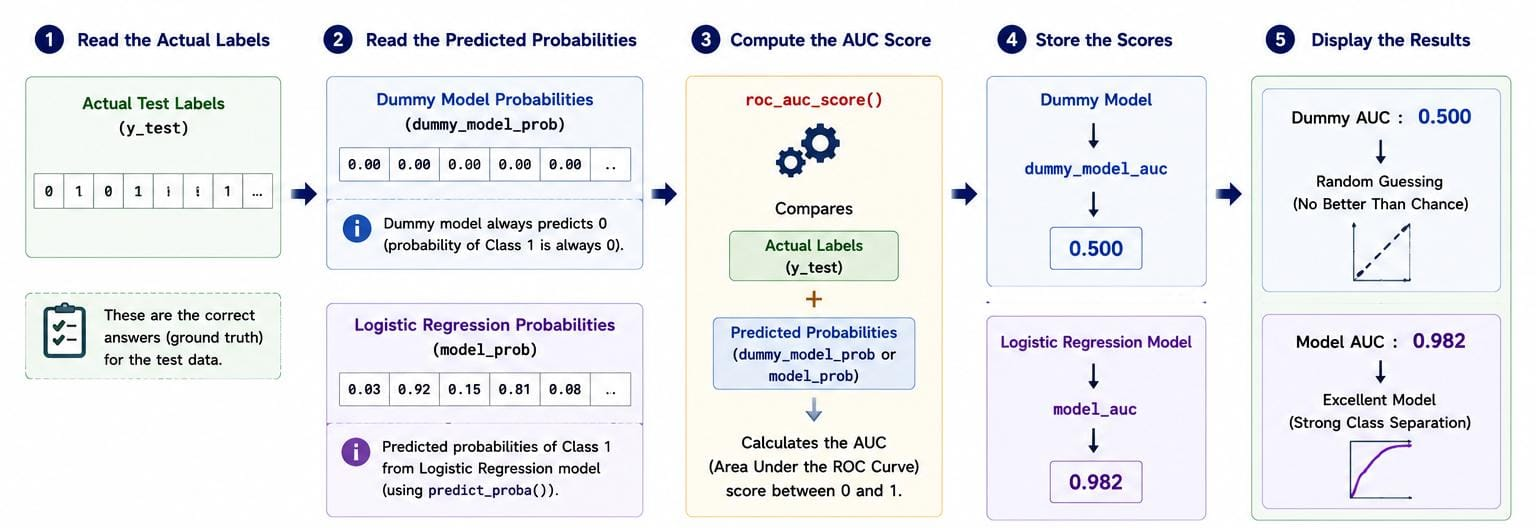

The dummy model's AUC should land right around **0.5** (random guessing), while our trained Logistic Regression model should score noticeably higher — showing it actually learned something useful.

## **Understanding False Positive Rate (FPR) & True Positive Rate (TPR)**

The **ROC (Receiver Operating Characteristic) Curve** is created using two important metrics:

- **False Positive Rate (FPR)**
- **True Positive Rate (TPR)**

These values are calculated at **many different decision thresholds**, and each pair of **FPR** and **TPR** forms a point on the ROC curve.

### **False Positive Rate (FPR)**

$$
FPR=\frac{FP}{FP+TN}
$$

The **False Positive Rate (FPR)** measures the proportion of **actual negative samples (Class 0)** that are **incorrectly predicted as positive (Class 1)**.

- **Lower FPR is better**, as it means the model makes fewer false positive predictions.

---

### **True Positive Rate (TPR)** *(Also called Recall or Sensitivity)*

$$
TPR=\frac{TP}{TP+FN}
$$

The **True Positive Rate (TPR)** measures the proportion of **actual positive samples (Class 1)** that are **correctly predicted as positive**.

- **Higher TPR is better**, as it means the model successfully identifies more positive samples.

---

## **How the ROC Curve is Created**

The model does not evaluate just one decision threshold (such as **0.5**). Instead, it evaluates **many different thresholds**.

At each threshold, a new **FPR** and **TPR** are calculated.

These **(FPR, TPR)** pairs are then plotted to create the **ROC Curve**.

As the decision threshold decreases:

- **TPR increases**, because the model identifies more positive samples.
- **FPR also increases**, because the model incorrectly classifies more negative samples as positive.

The ROC Curve visualizes this trade-off between **True Positive Rate** and **False Positive Rate** across **all possible decision thresholds**.

![ROC curve illustration](https://upload.wikimedia.org/wikipedia/commons/4/4f/ROC_curves.svg)

*Each curve traces (FPR, TPR) pairs as the threshold changes. The closer a curve hugs the top-left corner, the better the model. The diagonal line represents a random, no-skill classifier — like our dummy model. (Image: Wikimedia Commons, CC BY-SA 3.0)*

## **Calculate the ROC Curve Values**

To draw the **ROC (Receiver Operating Characteristic) Curve**, we first need to calculate three values:

- **False Positive Rate (FPR)** – The proportion of actual negative samples incorrectly predicted as positive.
- **True Positive Rate (TPR)** – The proportion of actual positive samples correctly predicted as positive.
- **Decision Thresholds** – Different probability cutoffs used to calculate FPR and TPR.

The `roc_curve()` function automatically evaluates the model at **many different thresholds** and returns the corresponding **FPR**, **TPR**, and **threshold** values. These values are then used to plot the ROC Curve.

In [8]:
# Calculate the False Positive Rate (FPR),
# True Positive Rate (TPR), and Thresholds
# for the Dummy Model.
dummy_fpr, dummy_tpr, _ = roc_curve(y_test, dummy_model_prob)

# Calculate the False Positive Rate (FPR),
# True Positive Rate (TPR), and Thresholds
# for the Logistic Regression model.
model_fpr, model_tpr, thresholds = roc_curve(y_test, model_prob)

In [9]:
# This line just previews the first 10 (FPR, TPR) pairs that will be plotted to draw the ROC curve.
list(zip(model_fpr[:10], model_tpr[:10]))

[(np.float64(0.0), np.float64(0.0)),
 (np.float64(0.0), np.float64(0.008)),
 (np.float64(0.0), np.float64(0.288)),
 (np.float64(0.008), np.float64(0.288)),
 (np.float64(0.008), np.float64(0.368)),
 (np.float64(0.016), np.float64(0.368)),
 (np.float64(0.016), np.float64(0.376)),
 (np.float64(0.024), np.float64(0.376)),
 (np.float64(0.024), np.float64(0.424)),
 (np.float64(0.032), np.float64(0.424))]

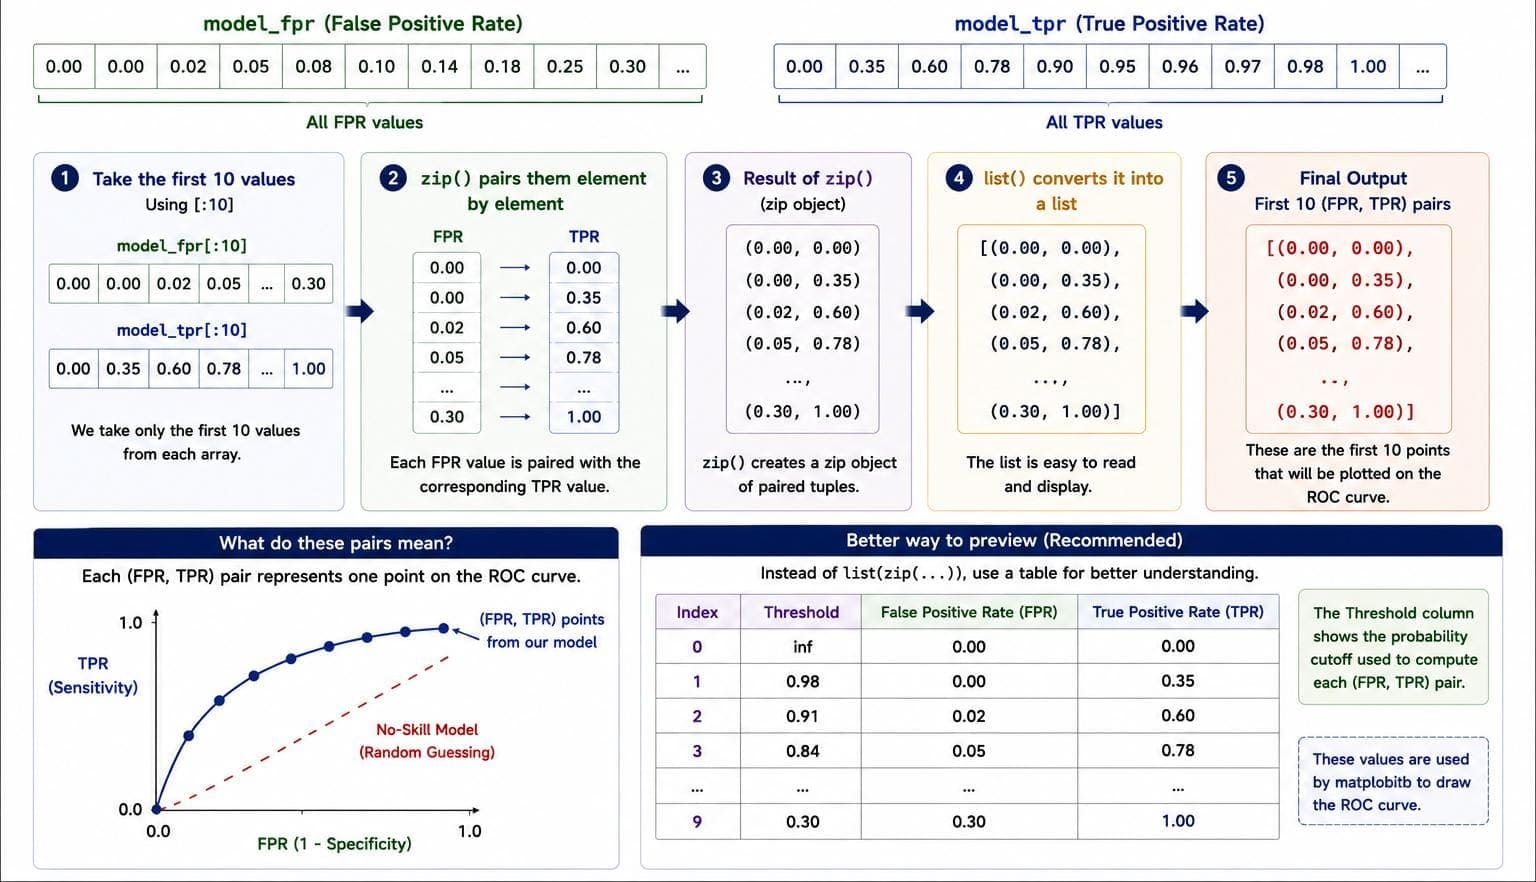

In [10]:
# preview the first 10 probability thresholds that were tested
thresholds[:10]

array([       inf, 0.99940859, 0.94878905, 0.9458758 , 0.93553523,
       0.93401146, 0.92807696, 0.92609822, 0.90946228, 0.90174308])

## **Plot the ROC Curve**

Now, we will visualize the **ROC (Receiver Operating Characteristic) Curve**.

The **dashed diagonal line** represents the **No-Skill (Dummy) Model**, which performs like **random guessing** and serves as a baseline for comparison.

The **solid curve** represents the **Logistic Regression model**. It is created by plotting the **False Positive Rate (FPR)** against the **True Positive Rate (TPR)** at many different decision thresholds.

A model with a ROC curve that is **closer to the top-left corner** has a **higher True Positive Rate** and a **lower False Positive Rate**, indicating better classification performance.

**In general, the farther the ROC curve is above the diagonal line and toward the top-left corner, the better the model is at distinguishing between the two classes.**

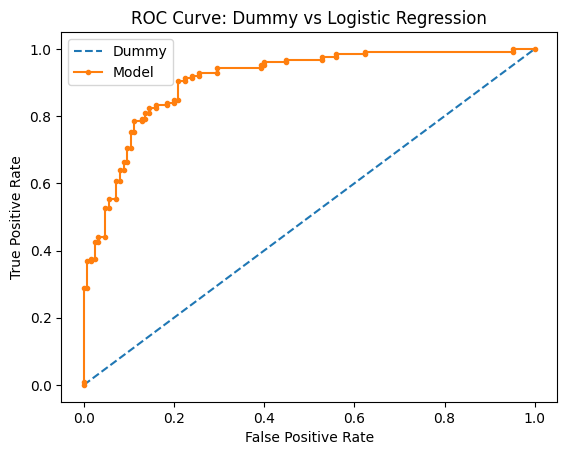

In [11]:
# plot the roc curve for the model
pyplot.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy')
pyplot.plot(model_fpr, model_tpr, marker='.', label='Model')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.title('ROC Curve: Dummy vs Logistic Regression')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

## **How Do We Select the Best Decision Threshold?**

So far, we have used the **default decision threshold of 0.5**.

This means:

- If the predicted probability is **greater than or equal to 0.5**, the model predicts **Class 1**.
- If the predicted probability is **less than 0.5**, the model predicts **Class 0**.

Although **0.5** is the default threshold used by most classification models, it is **not always the best choice**.

Changing the decision threshold changes the model's predictions, which also changes the **True Positive Rate (TPR)** and **False Positive Rate (FPR)**. As a result, the model moves to a different point on the **ROC Curve**.

### **What happens when we change the threshold?**

- **Higher Threshold (e.g., 0.8)**  
  The model predicts **Class 1** only when it is very confident.
  - Fewer positive predictions
  - Lower False Positive Rate (FPR)
  - Lower True Positive Rate (TPR), because some actual positive samples may be missed

- **Lower Threshold (e.g., 0.2)**  
  The model predicts **Class 1** more easily.
  - More positive predictions
  - Higher True Positive Rate (TPR)
  - Higher False Positive Rate (FPR), because more negative samples may be incorrectly classified as positive

### **Which Threshold Should We Choose?**

There is **no single threshold that is best for every problem**. The ideal threshold depends on the application and the cost of making different types of errors.

For example:

- **Disease Detection:** Missing a patient who actually has the disease can be very serious. In this case, a **lower threshold** is often preferred because it helps identify more positive cases.

- **Spam Email Detection:** Marking an important email as spam is usually more harmful than letting a spam email reach the inbox. In this case, a **higher threshold** may be preferred to reduce false positive predictions.

In the next step, we will **display the threshold values on the ROC Curve** so we can see how different thresholds affect the model's performance and identify the threshold that provides the best balance between **TPR** and **FPR**.

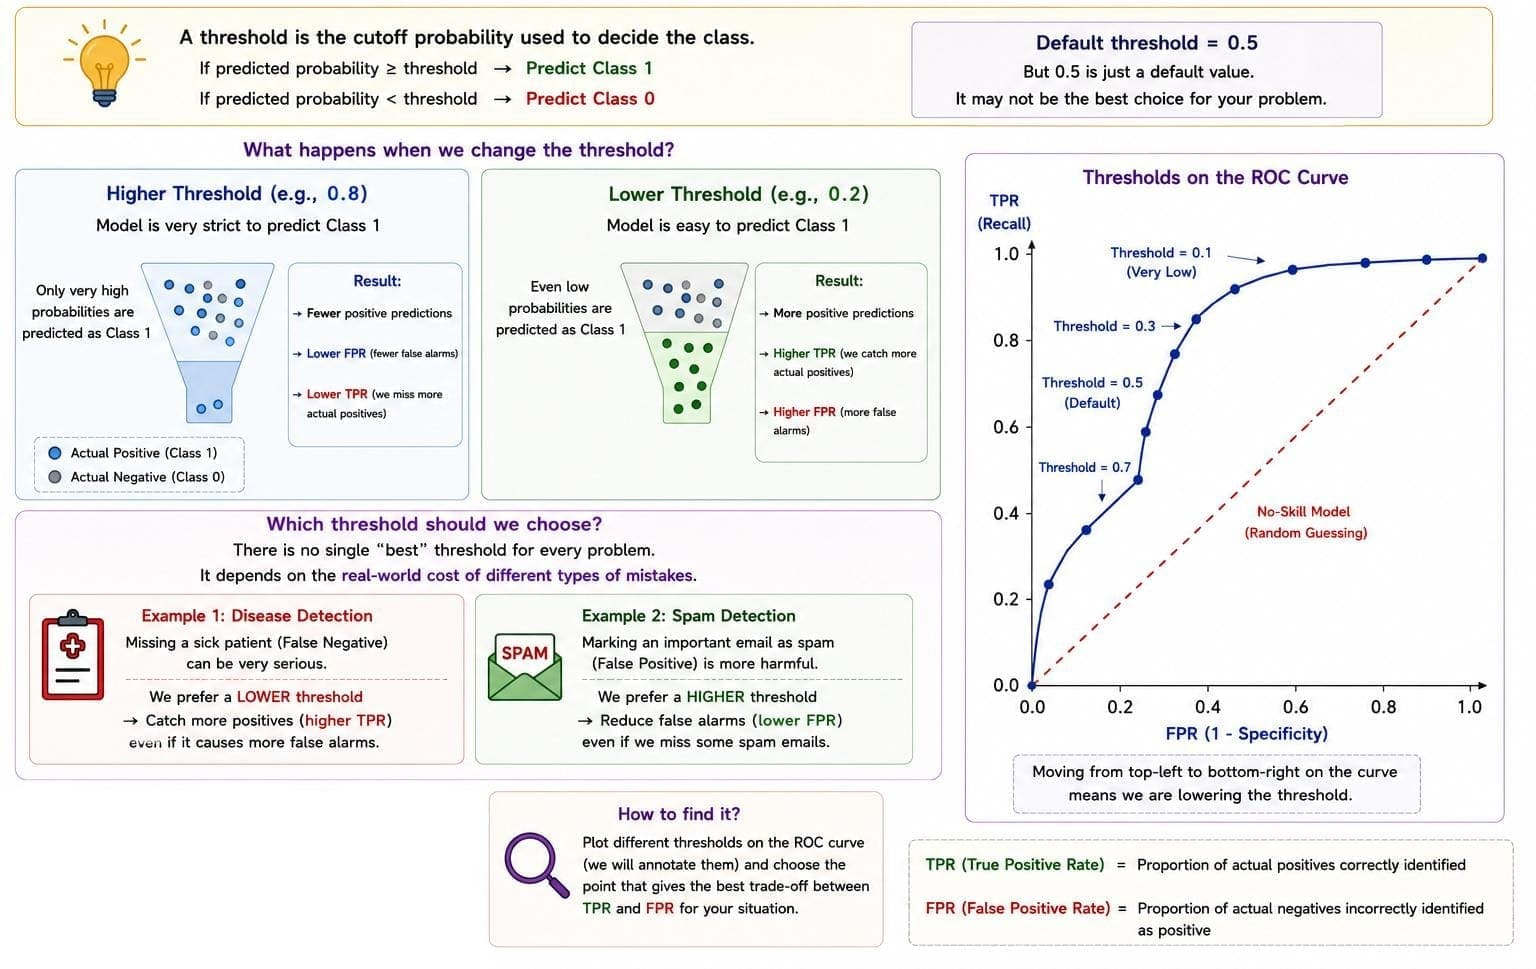

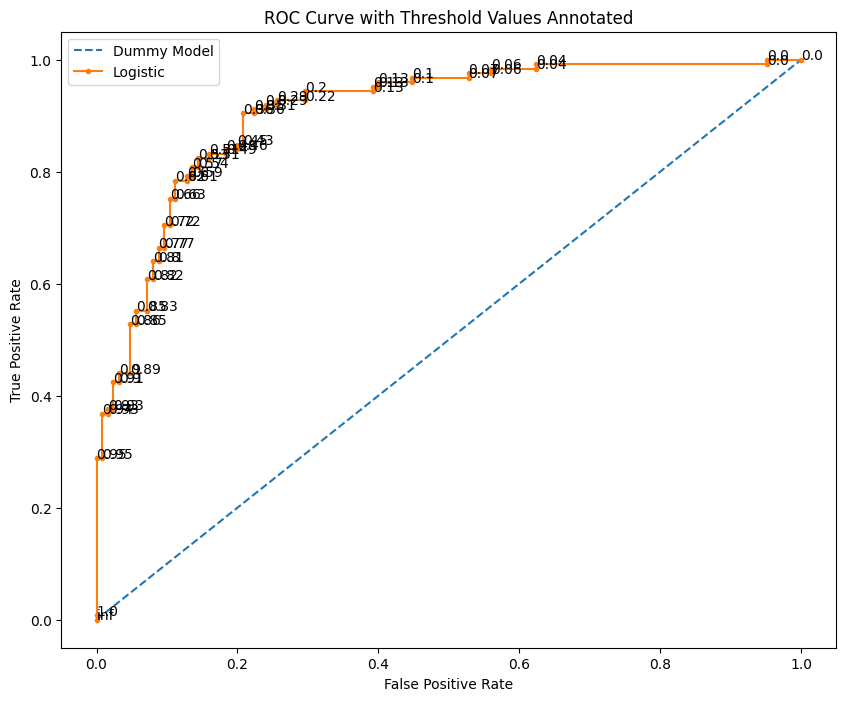

In [12]:
# plot the roc curve for the model, this time labeling each point with its threshold value
import numpy as np

fig = pyplot.figure(figsize=(10, 8))   # fixed: original figsize=(20,50) was a typo and made an unreadably huge plot
ax = fig.add_subplot(111)
ax.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
ax.plot(model_fpr, model_tpr, marker='.', label='Logistic')
for xyz in zip(model_fpr, model_tpr, thresholds):
    ax.annotate('%s' % np.round(xyz[2], 2), xy=(xyz[0], xyz[1]))
# axis Labels
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve with Threshold Values Annotated')
# show the Legend
ax.legend()
# show the plot
pyplot.show()

## **How Do We Select the Best Decision Threshold?**

In the previous section, we saw that **every point on the ROC Curve represents a different decision threshold**. The next question is:

> **Which threshold should we choose?**

One simple and widely used method is **Youden's J Statistic**.

It measures how well a threshold separates **Class 0** and **Class 1** by comparing the **True Positive Rate (TPR)** and the **False Positive Rate (FPR)**.

The formula is:

$$
J = TPR - FPR
$$

A **higher J value** indicates a better balance between correctly identifying positive samples (**high TPR**) and avoiding false positive predictions (**low FPR**).

To find the **best decision threshold**, we calculate the J value for every threshold on the ROC Curve and select the threshold that produces the **highest J value**.

Instead of estimating the best threshold by looking at the ROC Curve, we can calculate it directly using Youden's J Statistic.

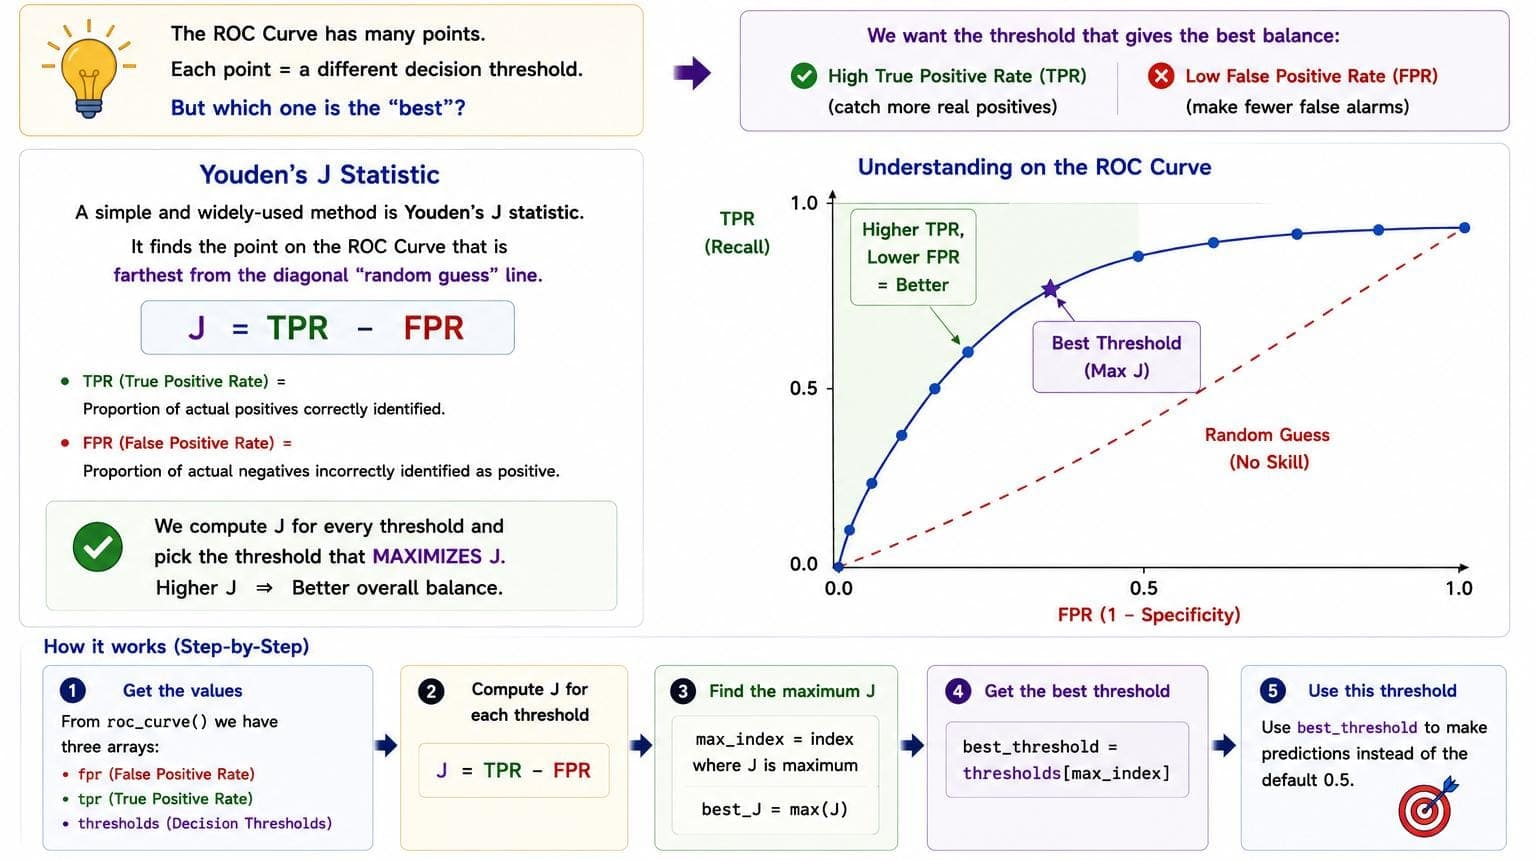

In [13]:
# Find the threshold that maximizes (TPR - FPR) — Youden's J statistic
J = model_tpr - model_fpr
best_index = np.argmax(J)
best_threshold = thresholds[best_index]

print("Best threshold (Youden's J):", round(best_threshold, 3))
print("At this threshold -> TPR: %.3f, FPR: %.3f" % (model_tpr[best_index], model_fpr[best_index]))

Best threshold (Youden's J): 0.365
At this threshold -> TPR: 0.904, FPR: 0.208


This gives us a **data-driven** cutoff instead of blindly assuming 0.5 is correct. If it comes out close to 0.5, great — the default was already reasonable for this dataset. If it's noticeably different, that's a sign the default threshold was leaving performance on the table.

## **Conclusion — What We Learned**

- **ROC Curve** plots True Positive Rate vs False Positive Rate across every possible classification threshold, not just 0.5.
- **AUC Score** condenses the whole curve into one number: 0.5 = random guessing, 1.0 = perfect separation.
- Comparing against a **dummy/no-skill baseline** tells us whether our model is actually learning anything.
- The **best threshold isn't always 0.5** — it depends on the real-world cost of false positives vs false negatives, and can be chosen systematically (e.g. via Youden's J statistic).

